In [15]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants

%matplotlib widget
# pybamm.set_logging_level("INFO")
# plt.rcParams.update({'font.size': 14})
pybamm.settings.max_smoothing = 0.2

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 11,
})

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Set up simulation

In [16]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Load data

In [17]:
Q_nom = 4.6
t_end = 5*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force', 'CO2 from CAN (ppm)']].loc[esc_start:esc_end].copy()
    data['Cell Temperature2'] = data['Cell Temperature'].copy() #make a copy 
    data['Cell Temperature'][data['Cell Temperature']>140] = None #filter original
    data.interpolate(inplace=True) #fill in nans for df
    data['Cell Temperature2'][data['Cell Temperature2']>140] = None #filter copy
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = data['Force']*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F','CO2', 'Temp2']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    # data['CO2'] = data.
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

display(load_data(0.75, '75')[0])

,t,V,Temp,I,F,CO2,Temp2,I_C,SOC
0,0.000,3.907343,21.886238,0.832958,138.377069,514,21.886238,0.181078,0.749301
1,0.100,1.447498,21.965434,230.630669,138.567582,514,21.965434,50.137102,0.747918
2,0.200,1.408588,21.896138,227.542398,139.107366,514,21.896138,49.465739,0.746547
3,0.300,1.388854,21.866438,226.594000,139.202622,514,21.866438,49.259565,0.745182
4,0.400,1.379884,21.995131,225.494177,139.361382,514,21.995131,49.020473,0.743822
...,...,...,...,...,...,...,...,...,...
2996,299.607,0.033070,89.170415,6.626894,148.569464,486,89.170415,1.440629,0.324614
2997,299.707,0.033229,89.151219,6.519304,149.013992,486,89.151219,1.417240,0.324574
2998,299.807,0.033110,89.141621,6.579076,148.347200,486,89.141621,1.430234,0.324535
2999,299.907,0.033189,89.122424,6.599000,149.299760,486,89.122424,1.434565,0.324495


C:\Users\Vivian\AppData\Local\Temp\ipykernel_29076\3095096665.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cell Temperature'][data['Cell Temperature']>140] = None #filter original
C:\Users\Vivian\AppData\Local\Temp\ipykernel_29076\3095096665.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cell Temperature2'][data['Cell Temperature2']>140] = None #filter copy
C:\Users\Vivian\AppData\Local\Temp\ipykernel_29076\3095096665.py:19: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axi

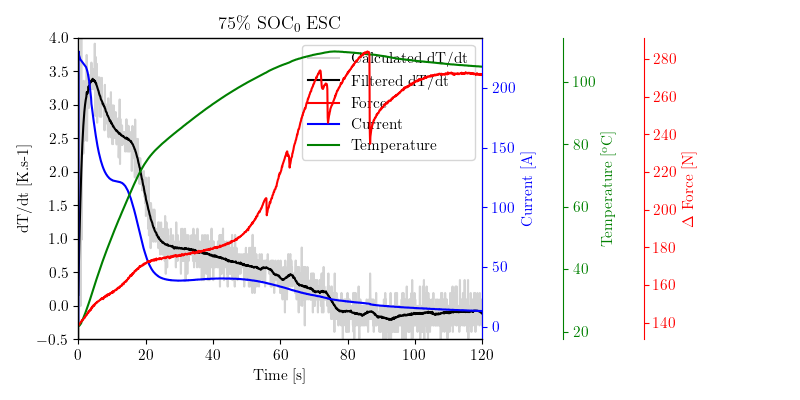

In [4]:
def plot_dT_time(SOC_0, SOC_name):
    data = load_data(SOC_0, SOC_name)[0]
    dTdt_data = np.diff(data.Temp)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

    # plot 
    fig, ax= plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
    # ax = ax.flatten()
    p1, = ax.plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Calculated dT/dt")
    p2, = ax.plot(data.t[0:-1], dT_filtered, color = 'k', label = "Filtered dT/dt")
    ax.set_ylabel("dT/dt [K.s-1]")
    ax.set_xlabel("Time [s]")
    ax.set_ylim([-0.5, 4])
    ax.set_xlim([0,t_end])

    ax2 = ax.twinx()
    p4, = ax2.plot(data.t, data.I, color = 'b', label = "Current")
    ax2.set_ylabel('Current [A]')
    ax2.yaxis.label.set_color(p4.get_color())
    ax2.tick_params(axis='y', colors=p4.get_color())
    ax2.spines.right.set_color(p4.get_color())

    ax3 = ax.twinx()
    ax3.spines.right.set_position(("axes", 1.2))
    p5, = ax3.plot(data.t, data.Temp, color = 'g', label = "Temperature")
    ax3.set_ylabel("Temperature [$^\mathrm{o}$C]")
    ax3.yaxis.label.set_color(p5.get_color())
    ax3.tick_params(axis='y', colors=p5.get_color())
    ax3.spines.right.set_color(p5.get_color())

    ax1 = ax.twinx()
    ax1.spines.right.set_position(("axes", 1.4))
    p3, = ax1.plot(data.t, data.F, color = 'r', label = "Force")
    ax1.set_ylabel("$\Delta$ Force [N]")
    ax1.yaxis.label.set_color(p3.get_color())
    ax1.tick_params(axis='y', colors=p3.get_color())
    ax1.spines.right.set_color(p3.get_color())

    plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")
    ax.legend(handles=[p1, p2, p3, p4, p5], loc = "upper right")
    plt.tight_layout()
    plt.show()

SOC_0 = 0.75
SOC_name = '75'
plot_dT_time(SOC_0, SOC_name)

In [5]:
def plot_dT_T(SOC_0, SOC_name):
    data = load_data(SOC_0, SOC_name)[0] 
    dTdt_data = np.diff(data.Temp)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

    # plot 
    t_plot_end = 120
    fig, ax= plt.subplots(1, 1, figsize=(8, 3))
    ax.plot(data.Temp[data.t<t_plot_end], dTdt_data[data.t[0:-1]<t_plot_end], color = "lightgrey", label = "Data")
    ax.plot(data.Temp[data.t<t_plot_end], dT_filtered[data.t[0:-1]<t_plot_end], color = "k", label = "Filtered")
    ax.set_xlabel("Temperature [degC]")
    ax.set_ylabel("dT/dt [K.s-1]")
    ax.legend()
    ax.set_ylim([-0.5, 4])
    ax.set_xlim([20,121])

    plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")

    T_bps = [110]

    for T in T_bps:
        ylims = ax.get_ylim()
        ax.plot([T]*2, list(ylims), color = 'grey', linestyle = '--')
        ax.annotate('Boiling point', xy=(T, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'grey')
        ax.set_ylim(ylims) # keep original limits

    if SOC_0 == 1: 
        chemistry = pybamm.parameter_sets.Tran2023
        param = pybamm.ParameterValues(chemistry)
        sigma_0 = data.F.iloc[0]/param['Active material surface area [m2]']/1000,
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
        ax.plot([T_vent]*2, list(ylims), color = 'm', linestyle = ':')
        ax.annotate('Venting', xy=(T_vent, np.diff(ylims)*0.6+ ylims[0]), rotation=-90, color = 'm')
    plt.tight_layout()
    plt.show()

# SOC_0 = 0.75
# SOC_name = '75'
# plot_dT_T(SOC_0, SOC_name)

# Nondimensional

## Check that model runs

In [6]:
def P_sat(T):
    P_dmc = 10**(6.4338-1413.0/(T-44.25))
    P_ec = 10**(6.4897-1836.57/(T-102.23))
    P = P_dmc*0.7 + P_ec*0.3  
    return P

def sim_venting(k_sei, k_A, T_offset = 0, F0 = np.nan):   
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    if np.isnan(F0):
        P0_sim =  data['F'].iloc[0]/param['Active material surface area [m2]']/1000
    else:
        P0_sim = F0/param['Active material surface area [m2]']/1000
        
    param.update({
        "Initial fraction of Li in SEI": 0.15*k_sei,
        "Frequency factor for SEI decomposition [s-1]": 2.25E15*k_A,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [ m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Initial cell compression stress [kPa]":P0_sim,
        "Critical venting pressure [kPa]": max(158.7731,(max(data['F']) )/param['Active material surface area [m2]']/1000 + 101)
    }, check_already_exists = False)
    
    # Define input and output
    T_vol_av = pybamm.Variable("Volume-averaged cell temperature [K]")
    x_sei = pybamm.Variable("Fraction of Li in SEI")
    delta_sigma = pybamm.Variable("Cell expansion stress [kPa]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged cell temperature [K]": T_vol_av,
        "Fraction of Li in SEI": x_sei,
        "Cell expansion stress [kPa]": delta_sigma,
    }
    model.external_variables = [T_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    k_b = pybamm.Scalar(constants.k)
    r_sei_dimensional = (
        -param.evaluate(thermal.A_sei)
        * x_sei
        * pybamm.exp(-param.evaluate(thermal.E_sei) / (k_b * T_vol_av))
    )  # units 1/s

    model.variables.update({
            "SEI decomposition reaction rate [s-1]": r_sei_dimensional,
        })

    # VENTING SUBMODEL
    P_crit = param.evaluate(thermal.P_crit)
    m_an = param.evaluate(thermal.m_an)
    x_sei_0 = param.evaluate(thermal.x_sei_0)
    M_C6 = param.evaluate(thermal.M_an)
    V_head_0 = param.evaluate(thermal.V_head_0)
    A_surf = param.evaluate(thermal.A_surf)
    L = param.evaluate(thermal.L_poron)
    E = param.evaluate(thermal.E_poron)
    alpha_cell = param.evaluate(thermal.alpha_cell)
    sigma_0 = param.evaluate(thermal.sigma_0)
    print(sigma_0)
    P_atm = param.evaluate(thermal.P_atm)
    delta_d = L/E*delta_sigma
    T_amb = param.evaluate(thermal.T_amb_dim(0))
    delta_T = T_vol_av-T_amb
    V_head = V_head_0 + A_surf*(delta_d-alpha_cell*delta_T)   
    # P_dmc = 10**(6.4338-1413.0/(T_vol_av-44.25))
    # P_ec = 10**(6.4897-1836.57/(T_vol_av-102.23)) 
    # P_sat_e = P_dmc*0.7 + P_ec*0.3 
    P_sat_e = P_sat(T_vol_av)
    n_CO2 = m_an*(x_sei_0 - x_sei)/(2*M_C6)
    # P_CO2 = pybamm.minimum(n_CO2*constants.R*T_vol_av/V_head/1000, P_crit) #kPa
    P_CO2 = n_CO2*constants.R*T_vol_av/V_head/1000 #kPa
    P_gas =  P_CO2 + P_sat_e 

    model.variables.update({
        "Thermal expansion stress of active material [kPa]": E*alpha_cell*delta_T/L,
        "Electrolyte gas saturation pressure [kPa]": P_sat_e,
        "CO2 gas pressure [kPa]": P_CO2,
        "Total gas pressure [kPa]": P_gas,
        "Amount of CO2 generated [mol]": n_CO2,
        "Headspace volume [m3]": V_head,
        # "Cell expansion summed stress [kPa]": E*alpha_cell*delta_T/L + P_gas - (sigma_0 + P_atm),
    })

    # RHS
    model.rhs = {
        x_sei: r_sei_dimensional,
    }
    model.algebraic = {
        delta_sigma: delta_sigma - pybamm.maximum(P_gas-P_atm-sigma_0, E*alpha_cell*delta_T/L),
        }

    # set initial conditions
    model.initial_conditions = {
        x_sei: param.evaluate(thermal.x_sei_0),
        delta_sigma: pybamm.Scalar(0),
        }

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # solve
    sim = pybamm.Simulation(model,parameter_values = param)

    T_input = data.Temp[0:-1]+273.15 + T_offset
    for i,(t, T) in enumerate(zip(data.t[0:-1], T_input)):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged cell temperature [K]": T}
        sim.step(dt, external_variables=external_variables)

    return sim

# SOC_0 = 0.75
# SOC_name = '75'
# data,T_amb_0 = load_data(SOC_0, SOC_name)
# sim = sim_venting(1,1) #0.1057 (100% t<80s), 0.04725 (75%)

## Plot data vs model

# PLOT: pressure contribution

In [10]:
SOC_name = '100A'
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})

# cells_solutions = []
# for SOC_name in SOC_names:
    # print(SOC_name) 
SOC_0 = SOC_0s[SOC_name]
data,T_amb_0 = load_data(SOC_0, SOC_name)
k_A = k_As[SOC_name]

solution = sim_venting(1,k_A).solution

15.0682938738


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


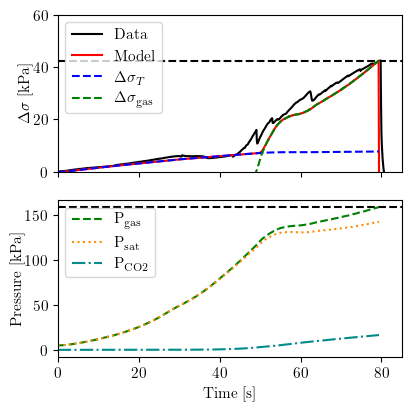

In [177]:
%matplotlib inline
fig, ax = plt.subplots(2,  1, figsize=(4, 4), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
ax = ax.flatten()
param = pybamm.ParameterValues('Tran2023')
A_surf = param["Active material surface area [m2]"]
P_atm = param["Atmospheric pressure [kPa]"]
sigma_0 = data['F'].iloc[0]/A_surf/1000
data_sigma = data.F/A_surf/1000 - sigma_0

sim_colors = ['r', 'b', 'g','darkorange', 'darkcyan']

# plot
t = np.array(data.t)
x_plot = t
xlabel = "Time [s]"

sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
sigma = solution["Cell expansion stress [kPa]"].entries
sigma_plot = sigma.copy()
vent_check = np.argmax(sigma_plot>sigma_max)
if vent_check > 0:
    sigma_plot[vent_check::] = 0
    t_vent_sim = np.round(data.t[np.where(sigma_plot==0)[0][0]], 4)
    try: 
        t_vent_data = data.t.iloc[np.where(data_sigma == sigma_max)[0][0]]
        e_t_vent = t_vent_sim -  t_vent_data

    except: 
        t_vent_data = data.t.iloc[-1]
        e_t_vent = float('nan')
    # print(e_t_vent)
else: 
    t_vent_sim = np.round(data.t.iloc[-1],4)
    e_t_vent = float('nan')

# x_plot = t[t<t_vent_sim].copy()

P_gas = solution["Total gas pressure [kPa]"].entries
P_co2 = solution["CO2 gas pressure [kPa]"].entries #- sigma_0
P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries #- sigma_0-P_atm
sigma_T = solution["Thermal expansion stress of active material [kPa]"].entries# *A_surf*1000

# plot delta_sigma
ax[0].plot(data.t, data_sigma, color = 'k', label = 'Data') #: (F-F$_0$)/A$_{surf}$
ax[0].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle='--', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
ax[0].plot(x_plot[t<t_vent_sim], sigma_plot[t<t_vent_sim],linestyle='-', color = sim_colors[0], label = 'Model')
ax[0].plot(x_plot[t<t_vent_sim], sigma_T[t<t_vent_sim],linestyle='--', color = sim_colors[1], label = "$\Delta\sigma_T$")
ax[0].plot(x_plot[t<t_vent_sim], P_gas[t<t_vent_sim] - P_atm - sigma_0,linestyle='--', color = sim_colors[2], label = "$\Delta\sigma_{\mathrm{gas}}$") #=P$_\mathrm{{gas}}$-P$_0$ - P$_\mathrm{{atm}}$
ax[0].set_xlim([0,85])
ax[0].set_ylim([0,60])
ax[0].set_ylabel("$\Delta\sigma$ [kPa]",labelpad=0)

# plot P
P_max = max(57.531322623700014 + P_atm, max(data.F)/A_surf/1000) # from either 100% (default) or 100%F cell
ax[1].plot([x_plot[0], x_plot[-1]], P_max*np.array([1,1]) , linestyle='--', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
ax[1].plot(x_plot[t<t_vent_sim], P_gas[t<t_vent_sim],linestyle='--', color = sim_colors[2], label = "P$_\mathrm{{gas}}$") #=P$_\mathrm{{sat}}$+P$_\mathrm{{CO2}}$
ax[1].plot(x_plot[t<t_vent_sim], P_elyte[t<t_vent_sim],linestyle=':', color = sim_colors[3], label = "P$_{\mathrm{sat}}$ ") #= P$_\mathrm{{sat}}$$
ax[1].plot(x_plot[t<t_vent_sim], P_co2[t<t_vent_sim], linestyle='-.', color = sim_colors[4], label = "P$_\mathrm{{CO2}}$")
# ax[1].set_ylim([0,60 + P_atm + sigma_0])
ax[1].set_ylabel("Pressure [kPa]",labelpad=0)
ax[1].set_xlabel(xlabel)

handles0, labels0 = ax[0].get_legend_handles_labels()
handles1, labels1 = ax[1].get_legend_handles_labels()

# fig.legend(handles0 + handles1, labels0 + labels1, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1.15))
ax[0].legend(loc = 'upper left', ncol =1) # loc = 'upper center', ncol = 4
ax[1].legend(loc = 'upper left') # loc = 'upper center', ncol = 3
plt.savefig('./figs/exp_component_split.eps', format='eps', dpi = 300)

# fig.legend(ncol = 2, )

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


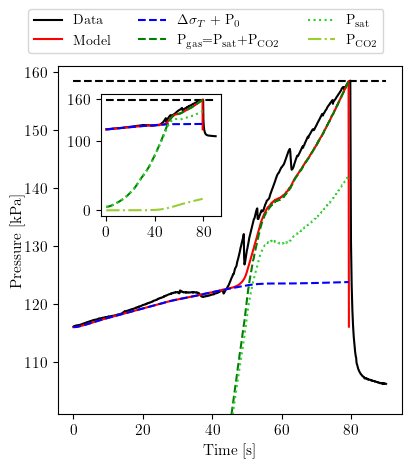

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(1,  1, figsize=(4, 4), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
param = pybamm.ParameterValues('Tran2023')
A_surf = param["Active material surface area [m2]"]
P_atm = param["Atmospheric pressure [kPa]"]
P_0 = data['F'].iloc[0]/A_surf/1000 + P_atm
data.P = data.F/A_surf/1000 + P_atm

sim_colors = ['r', 'b', 'g','limegreen', 'yellowgreen']
# sim_colors = ['r', 'b', 'darkorange','sandybrown', 'gold']

# plot
t = np.array(data.t)
x_plot = t
xlabel = "Time [s]"

P_max = max(57.531322623700014 + P_atm, max(data.P)) # from either 100% (default) or 100%F cell
sigma = solution["Cell expansion stress [kPa]"].entries
sigma_plot = sigma.copy() + P_0
vent_check = np.argmax(sigma_plot>P_max)
if vent_check > 0:
    sigma_plot[vent_check::] = P_0
    t_vent_sim = np.round(data.t[np.where(sigma_plot==P_0)[0][0]], 4)
    try: 
        t_vent_data = data.t.iloc[np.where(data.O == P_max)[0][0]]
        e_t_vent = t_vent_sim -  t_vent_data

    except: 
        t_vent_data = data.t.iloc[-1]
        e_t_vent = float('nan')
    # print(e_t_vent)
else: 
    t_vent_sim = np.round(data.t.iloc[-1],4)
    e_t_vent = float('nan')

# x_plot = t[t<t_vent_sim].copy()

P_gas = solution["Total gas pressure [kPa]"].entries
P_co2 = solution["CO2 gas pressure [kPa]"].entries #- sigma_0
P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries #- sigma_0-P_atm
# P_elyte = P_sat #- sigma_0 - P_atm
P_T = solution["Thermal expansion stress of active material [kPa]"].entries + P_0# *A_surf*1000
P_gas = P_elyte + P_co2 #- sigma_0 - P_atm

ax.plot(data.t, data.P, color = 'k', label = 'Data') #: (F-F$_0$)/A$_{surf}$
ax.plot([x_plot[0], x_plot[-1]], P_max*np.array([1,1]) , linestyle='--', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
ax.plot(x_plot[t<t_vent_sim], sigma_plot[t<t_vent_sim],linestyle='-', color = sim_colors[0], label = 'Model') #: max($\Delta\sigma_T$, $\mathrm{P_{gas}}$)
ax.plot(x_plot[t<t_vent_sim], P_T[t<t_vent_sim],linestyle='--', color = sim_colors[1], label = "$\Delta\sigma_T$ + P$_0$")
ax.plot(x_plot[t<t_vent_sim], P_gas[t<t_vent_sim],linestyle='--', color = sim_colors[2], label = "P$_\mathrm{{gas}}$=P$_\mathrm{{sat}}$+P$_\mathrm{{CO2}}$")
ax.plot(x_plot[t<t_vent_sim], P_elyte[t<t_vent_sim],linestyle=':', color = sim_colors[3], label = "P$_{\mathrm{sat}}$ ") #= P$_\mathrm{{sat}}$ - P$_0$
ax.plot(x_plot[t<t_vent_sim], P_co2[t<t_vent_sim], linestyle='-.', color = sim_colors[4], label = "P$_\mathrm{{CO2}}$")
ax.set_xlabel(xlabel)
# ax.set_xlim([0,90])
ax.set_ylim([P_atm,P_atm+60])
ax.set_ylabel("Pressure [kPa]",labelpad=0)


# plot inset
ax2 = ax.inset_axes([.125, .57, .35, .35],xlim = (ax.get_xlim()), xticks=[0,40,80], yticks=[0,100,160])  # subregion of original plot yticklabels=[]
# ax2.yaxis.tick_right()
ax2.plot(data.t, data.P, color = 'k', label = 'Data') #: (F-F$_0$)/A$_{surf}$
ax2.plot([x_plot[0], x_plot[-1]], P_max*np.array([1,1]) , linestyle='--', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
ax2.plot(x_plot[t<t_vent_sim], sigma_plot[t<t_vent_sim],linestyle='-', color = sim_colors[0])
ax2.plot(x_plot[t<t_vent_sim], P_T[t<t_vent_sim],linestyle='--', color = sim_colors[1])
ax2.plot(x_plot[t<t_vent_sim], P_gas[t<t_vent_sim],linestyle='--', color = sim_colors[2])
ax2.plot(x_plot[t<t_vent_sim], P_elyte[t<t_vent_sim],linestyle=':', color = sim_colors[3]) #= P$_\mathrm{{sat}}$ - P$_0$
ax2.plot(x_plot[t<t_vent_sim], P_co2[t<t_vent_sim], linestyle='-.', color = sim_colors[4])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1.15))
plt.savefig('./figs/exp_component_pressure.eps', format='eps', dpi = 300)

# fig.legend(ncol = 2, )

-0.4000000000000057


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


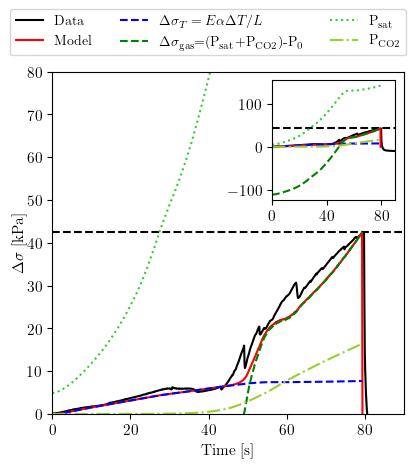

In [36]:
%matplotlib inline
fig, ax = plt.subplots(1,  1, figsize=(4, 4), sharex=True, gridspec_kw = {'wspace':0.3, 'hspace':0.1}, constrained_layout=True)#, constrained_layout=True
param = pybamm.ParameterValues('Tran2023')
A_surf = param["Active material surface area [m2]"]
sigma_0 = data['F'].iloc[0]/A_surf/1000
data_sigma = data.F/A_surf/1000 - sigma_0
P_atm = param["Atmospheric pressure [kPa]"]

sim_colors = ['r', 'b', 'g','limegreen', 'yellowgreen']
# sim_colors = ['r', 'b', 'darkorange','sandybrown', 'gold']

# plot
t = np.array(data.t)
x_plot = t
xlabel = "Time [s]"

sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
sigma = solution["Cell expansion stress [kPa]"].entries
sigma_plot = sigma.copy()
vent_check = np.argmax(sigma_plot>sigma_max)
if vent_check > 0:
    sigma_plot[vent_check::] = 0  
    t_vent_sim = np.round(data.t[np.where(sigma_plot==0)[0][0]], 4)
    try: 
        t_vent_data = data.t.iloc[np.where(data_sigma == sigma_max)[0][0]]
        e_t_vent = t_vent_sim -  t_vent_data

    except: 
        t_vent_data = data.t.iloc[-1]
        e_t_vent = float('nan')
    print(e_t_vent)
else: 
    t_vent_sim = np.round(data.t.iloc[-1],4)
    e_t_vent = float('nan')

# x_plot = t[t<t_vent_sim].copy()

P_gas = solution["Total gas pressure [kPa]"].entries
P_co2 = solution["CO2 gas pressure [kPa]"].entries #- sigma_0
P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries #- sigma_0-P_atm
# P_elyte = P_sat #- sigma_0 - P_atm
P_T = solution["Thermal expansion stress of active material [kPa]"].entries # *A_surf*1000
P_gas = P_elyte + P_co2 - sigma_0 - P_atm

ax.plot(data.t, data_sigma, color = 'k', label = 'Data') #: (F-F$_0$)/A$_{surf}$
ax.plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle='--', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
ax.plot(x_plot[t<t_vent_sim], sigma_plot[t<t_vent_sim],linestyle='-', color = sim_colors[0], label = 'Model') #: max($\Delta\sigma_T$, $\mathrm{P_{gas}}$)
ax.plot(x_plot[t<t_vent_sim], P_T[t<t_vent_sim],linestyle='--', color = sim_colors[1], label = r"$\Delta\sigma_T=E\alpha \Delta T/L$")
ax.plot(x_plot[t<t_vent_sim], P_gas[t<t_vent_sim],linestyle='--', color = sim_colors[2], label = "$\Delta\sigma_{\mathrm{gas}}$=(P$_\mathrm{{sat}}$+P$_\mathrm{{CO2}}$)-P$_0$")
ax.plot(x_plot[t<t_vent_sim], P_elyte[t<t_vent_sim],linestyle=':', color = sim_colors[3], label = "P$_{\mathrm{sat}}$ ") #= P$_\mathrm{{sat}}$ - P$_0$
ax.plot(x_plot[t<t_vent_sim], P_co2[t<t_vent_sim], linestyle='-.', color = sim_colors[4], label = "P$_\mathrm{{CO2}}$")
ax.set_xlabel(xlabel)
ax.set_xlim([0,90])
ax.set_ylim([0,80])
ax.set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)


# plot inset
ax2 = ax.inset_axes([.625, .625, .35, .35],xlim = (ax.get_xlim()), xticks=[0,40,80])  # subregion of original plot yticklabels=[]
# ax2.yaxis.tick_right()
ax2.plot(data.t, data_sigma, color = 'k', label = 'Data') #: (F-F$_0$)/A$_{surf}$
ax2.plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle='--', color = 'k') #(out.P_est-P_atm)/1000-sigma_0/1000
ax2.plot(x_plot[t<t_vent_sim], sigma_plot[t<t_vent_sim],linestyle='-', color = sim_colors[0])
ax2.plot(x_plot[t<t_vent_sim], P_T[t<t_vent_sim],linestyle='--', color = sim_colors[1])
ax2.plot(x_plot[t<t_vent_sim], P_gas[t<t_vent_sim],linestyle='--', color = sim_colors[2])
ax2.plot(x_plot[t<t_vent_sim], P_elyte[t<t_vent_sim],linestyle=':', color = sim_colors[3]) #= P$_\mathrm{{sat}}$ - P$_0$
ax2.plot(x_plot[t<t_vent_sim], P_co2[t<t_vent_sim], linestyle='-.', color = sim_colors[4])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1.15))
plt.savefig('./figs/exp_component.eps', format='eps', dpi = 300)

# fig.legend(ncol = 2, )

## PLOT: Amount of CO2 generated 

0.05426070997901796
0.2034041006999668
0.8631187849499481
16.633333333333333


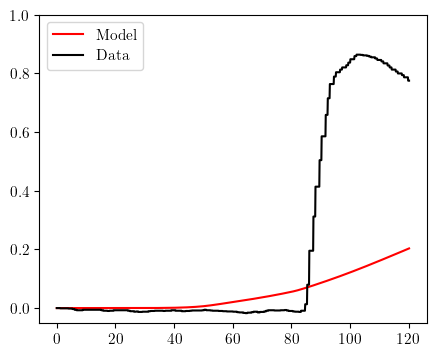

In [37]:
%matplotlib inline
# param = pybamm.ParameterValues('Tran2023')
# A_surf = param["Active material surface area [m2]"]
# sigma_0 = data.F.iloc[0]/A_surf/1000
# # data.P = data.F/A_surf/1000
# # max(data.F/A_surf/1000 ) - data['F'].iloc[0]/A_surf/1000
# print(sigma_max)
# print(P_max-P_0)
print(solution["Amount of CO2 generated [mol]"].entries[(abs(t-t_vent_sim)).argmin()]*1000) #mmol
print(max(solution["Amount of CO2 generated [mol]"].entries*1000)) #mmol
print((1551-500)/1000*1.293/0.02897*0.0184)
print((1126-128)/60)

fig, ax = plt.subplots(1,  1, figsize=(5, 4))
t = np.array(data.t)
n_CO2 = solution["Amount of CO2 generated [mol]"].entries*1000 #mmol
ax.plot(t, n_CO2, color = 'red', label = 'Model')
ax.plot(t, (data.CO2 - data.CO2.iloc[0])/1000*1.293/0.02897*0.0184, color = 'k', label = 'Data')
ax.set_ylim([-0.05,1])

# x_sei = solution["Fraction of Li in SEI"].entries
# ax2 = ax.twinx()
# p4, = ax2.plot(t, x_sei)
# ax2.yaxis.label.set_color(p4.get_color())
# ax2.tick_params(axis='y', colors=p4.get_color())
# ax2.spines.right.set_color(p4.get_color())

plt.legend()
                       

# PLOT: Effect of preload

In [167]:
SOC_name = '100A'
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})

cells_solutions = []
F0s = [0,250,500,1000]
for F0 in F0s:
    # print(F0) 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    k_A = k_As[SOC_name]
    cells_solutions.append(sim_venting(1,k_A,F0 = F0).solution)


0.0
27.777777777777782
55.555555555555564
111.11111111111113


15.0682938738


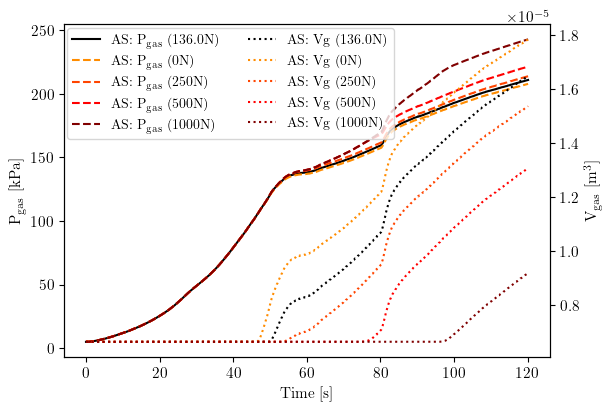

In [173]:
%matplotlib inline

param = pybamm.ParameterValues('Tran2023')
A_surf = param["Active material surface area [m2]"]

# nominal solution
nom_solution = sim_venting(1,k_A,F0 = data.F[0]).solution
P_gas0 = nom_solution["Total gas pressure [kPa]"].entries
Vh0 = nom_solution["Headspace volume [m3]"].entries

# plot nom + other solutions
fig, ax = plt.subplots(1,  1, figsize=(6, 4), constrained_layout=True)
ax2 = ax.twinx()

ax.plot(t, P_gas0,'-k', label = "AS: P$_\mathrm{{gas}}$ (" + str(np.round(data.F[0])) + "N)") #  (F$_0$ = " + str(np.round(F0)) + ")"
ax2.plot(t, Vh0, ':k', label = "AS: Vg (" + str(np.round(data.F[0])) + "N)")

cmap = ['darkorange','orangered', 'red', 'maroon']
for i, (solution, F0) in enumerate(zip(cells_solutions, F0s)):
    sigma_0 = F0/A_surf/1000
    n_CO2 = solution["Amount of CO2 generated [mol]"].entries #mol
    P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries
    P_gas = solution["Total gas pressure [kPa]"].entries
    P_co2 = solution["CO2 gas pressure [kPa]"].entries 
    Vh = solution["Headspace volume [m3]"].entries
    
    # plot
    t = np.array(data.t)
    ax.plot(t, P_gas,'--',  color = cmap[i], label = "AS: P$_\mathrm{{gas}}$ (" + str(np.round(F0)) + "N)") #  (F$_0$ = " + str(np.round(F0)) + ")"
    ax2.plot(t, Vh, ':', color = cmap[i] , label = "AS: Vg (" + str(np.round(F0)) + "N)")
    ax2.set_ylabel('V$_{\mathrm{gas}}$ [m$^3$]')
    # ax2.set_ylim([0,5e-3])

ax.set_xlabel('Time [s]')
ax.set_ylabel('P$_{\mathrm{gas}}$ [kPa]')

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1+handles2, labels1+labels2, loc='upper left', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.09, .96))


57.4210734838
29.64329570602222
1.8655179282444365
-53.69003762731113


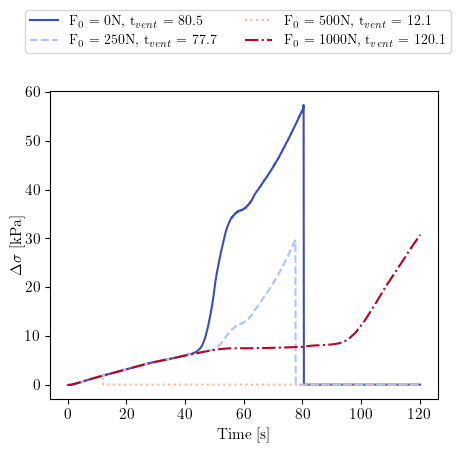

In [64]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
A_surf = param["Active material surface area [m2]"]
data_sigma = (data.F-data['F'].iloc[0])/A_surf/1000 
# P_atm = param["Atmospheric pressure [kPa]"]
data.P = data.F/A_surf/1000 + P_atm

fig, ax = plt.subplots(1,  1, figsize=(5, 4))
t = np.array(data.t)
# ax.plot(data.t, data.P, color = 'k', label = 'Data') #: (F-F$_0$)/A$_{surf}$
linestyles = ['-', '--', ':', '-.']*2
for i, (solution, F0) in enumerate(zip(cells_solutions, F0s)):
    param = pybamm.ParameterValues('Tran2023')
    A_surf = param["Active material surface area [m2]"]
    sigma_0 = F0/A_surf/1000
    # data_sigma = data.F/A_surf/1000 - sigma_0
    P_atm = param["Atmospheric pressure [kPa]"]
    P_0 = F0/A_surf/1000 + P_atm 
    cmap = plt.get_cmap('coolwarm',len(F0s))

    # plot
    t = np.array(data.t)
    P_gas = solution["Total gas pressure [kPa]"].entries
    P_co2 = solution["CO2 gas pressure [kPa]"].entries #- sigma_0
    P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries #- sigma_0-P_atm
    sigma_T = solution["Thermal expansion stress of active material [kPa]"].entries # *A_surf*1000
    P_gas = P_elyte + P_co2 #- sigma_0 - P_atm

    # sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    delta_sigma_max = (42.35277961+15.0682938738) - sigma_0 # delta_sigma_max
    print(delta_sigma_max)
    delta_sigma = solution["Cell expansion stress [kPa]"].entries
    delta_sigma_plot = delta_sigma.copy()
    vent_check = np.argmax(delta_sigma_plot>delta_sigma_max)
    if vent_check > 0:
        delta_sigma_plot[vent_check::] = 0
        t_vent_sim = np.round(data.t[np.where(delta_sigma_plot==0)[0][0]], 4)
        try: 
            t_vent_data = data.t.iloc[np.where(delta_sigma_plot == delta_sigma_max)[0][0]]
            e_t_vent = t_vent_sim -  t_vent_data

        except: 
            t_vent_data = data.t.iloc[-1]
            e_t_vent = float('nan')
        # print(e_t_vent)
    else: 
        t_vent_sim = np.round(data.t.iloc[-1],4)
        e_t_vent = float('nan')
    sim_label = 'F$_0$ = ' + str(np.round(F0)) + 'N, t$_{vent}$ = ' + str(np.round(t_vent_sim,3))
    # ax.plot(t, sigma_T, color = cmap(i), label = '_nolegend_', linestyle = linestyles[i])
    ax.plot(t, delta_sigma_plot, color = cmap(i), label = sim_label, linestyle = linestyles[i])
    # ax.plot(t, sigma_plot, color = cmap(i), label = sim_label, linestyle = linestyles[i])

ax.set_xlabel('Time [s]')
ax.set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
# plt.legend()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, 1.1))

plt.show()
# ax.set_xlim(0,90)


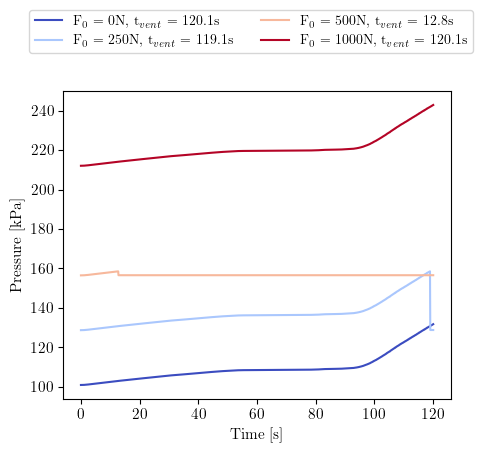

In [69]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
A_surf = param["Active material surface area [m2]"]
data_sigma = (data.F-data['F'].iloc[0])/A_surf/1000 
# P_atm = param["Atmospheric pressure [kPa]"]
data.P = data.F/A_surf/1000 + P_atm

fig, ax = plt.subplots(1,  1, figsize=(5, 4))
t = np.array(data.t)
# ax.plot(data.t, data.P, color = 'k', label = 'Data') #: (F-F$_0$)/A$_{surf}$

for i, (cell_solution, F0) in enumerate(zip(cells_solutions, F0s)):
    param = pybamm.ParameterValues('Tran2023')
    A_surf = param["Active material surface area [m2]"]
    sigma_0 = F0/A_surf/1000
    # data_sigma = data.F/A_surf/1000 - sigma_0
    P_atm = param["Atmospheric pressure [kPa]"]
    P_0 = sigma_0 + P_atm 
    cmap = plt.get_cmap('coolwarm',len(F0s))

    # plot
    t = np.array(data.t)
    P_max = max(57.531322623700014 + P_atm, max(data.P)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy() + P_0
    vent_check = np.argmax(sigma_plot>P_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = P_0
        t_vent_sim = np.round(data.t[np.where(sigma_plot==P_0)[0][0]], 4)
        try: 
            t_vent_data = data.t.iloc[np.where(data.O == P_max)[0][0]]
            e_t_vent = t_vent_sim -  t_vent_data

        except: 
            t_vent_data = data.t.iloc[-1]
            e_t_vent = float('nan')
        # print(e_t_vent)
    else: 
        t_vent_sim = np.round(data.t.iloc[-1],4)
        e_t_vent = float('nan')
    sim_label = 'F$_0$ = ' + str(np.round(F0)) + 'N, t$_{vent}$ = ' + str(t_vent_sim) + 's'
    ax.plot(t, sigma_plot, color = cmap(i), label = sim_label)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Pressure [kPa]')
# plt.legend()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, 1.1))

plt.show()
# ax.set_xlim(0,90)


# PLOT: Analytic solution verification

In [174]:
SOC_name = '100A'
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})

SOC_0 = SOC_0s[SOC_name]
data,T_amb_0 = load_data(SOC_0, SOC_name)
k_A = k_As[SOC_name]

solution = sim_venting(1,k_A).solution

15.0682938738


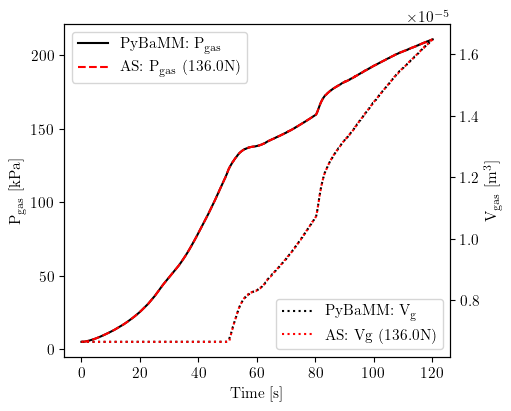

In [166]:
%matplotlib inline
A_surf = param["Active material surface area [m2]"]
P_atm = param["Atmospheric pressure [kPa]"]
thermal = pybamm.thermal_parameters
V_head_0 = param.evaluate(thermal.V_head_0)
A_surf = param.evaluate(thermal.A_surf)
L = param.evaluate(thermal.L_poron)
E = param.evaluate(thermal.E_poron)
alpha_cell = param.evaluate(thermal.alpha_cell)
T_amb = param["Ambient temperature [K]"]
# T_amb = data.Temp[0]
t = np.array(data.t)

n_CO2 = solution["Amount of CO2 generated [mol]"].entries #mol
P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries
P_gas = solution["Total gas pressure [kPa]"].entries
P_co2 = solution["CO2 gas pressure [kPa]"].entries #- sigma_0
# P_gas = P_elyte + P_co2 #- sigma_0 - P_atm
Vh = solution["Headspace volume [m3]"].entries

F0s = [data.F[0]]
fig, ax = plt.subplots(1,  1, figsize=(5, 4), constrained_layout=True)
ax.plot(t, P_gas, 'k', label = 'PyBaMM: P$_{\mathrm{gas}}$')
# ax.plot(t, P_co2, '--k', label = 'PyBaMM: P$_{\mathrm{co2}}$')

ax2 = ax.twinx()
ax2.plot(t, Vh, ':k', label = 'PyBaMM: V$_{\mathrm{g}}$')

for F0 in F0s:
    sigma_0 = F0/A_surf/1000
    delta_sigma_calc = P_elyte - sigma_0 - P_atm  #kPa

    # calculate Vg
    b = V_head_0 + A_surf*L/E*(delta_sigma_calc) - A_surf*alpha_cell*(data.Temp+273.15-T_amb)
    c = A_surf*L/E*n_CO2*(constants.R/1000)*(data.Temp+273.15)
    Vg_calc = (b+np.sqrt(b**2+4*c))/2
    Vg = np.array([max(Vg_calc0, V_head_0) for Vg_calc0 in Vg_calc]) # min Vg = V_head_0
    # Vg = (b+np.sqrt(b**2+4*c))/2

    # calculate P_gas
    # P_CO2_calc = (n_CO2*(constants.R/1000)*(data.Temp+273.15)/Vh) # using Vh from sim
    P_CO2_calc = (n_CO2*(constants.R/1000)*(data.Temp+273.15)/Vg) 
    P_gas_calc = P_elyte + P_CO2_calc
    
    # plot
    t = np.array(data.t)
    ax.plot(t, P_gas_calc,'--r', label = "AS: P$_\mathrm{{gas}}$ (" + str(np.round(F0)) + "N)") #  (F$_0$ = " + str(np.round(F0)) + ")"
    # ax.plot(t, P_CO2_calc,'--r', label = "Analytic soln  P$_\mathrm{{CO2}}$" ) #P_CO2_calc (F$_0$ = " + str(np.round(F0)) + ")")    
    ax2.plot(t, Vg, ':r', label = "AS: Vg (" + str(np.round(F0)) + "N)")
    ax2.set_ylabel('V$_{\mathrm{gas}}$ [m$^3$]')
    # ax2.set_ylim([0,5e-3])



ax.set_xlabel('Time [s]')
ax.set_ylabel('P$_{\mathrm{gas}}$ [kPa]')
# ax.set_ylim([0, 225])
ax.legend() #loc = 'upper center'
ax2.legend(loc = 'lower right') #

# PLOT: Analytic solution with effect of preload

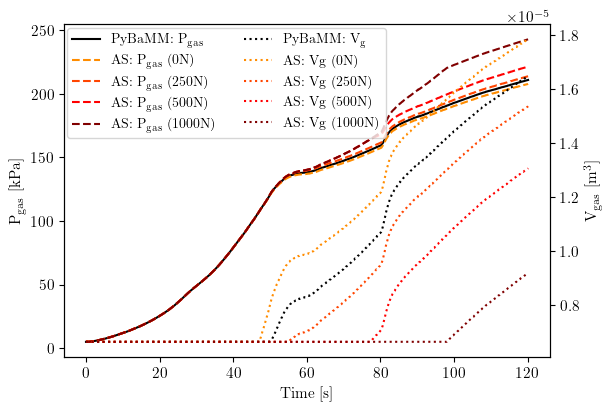

In [175]:
%matplotlib inline
A_surf = param["Active material surface area [m2]"]
P_atm = param["Atmospheric pressure [kPa]"]
thermal = pybamm.thermal_parameters
V_head_0 = param.evaluate(thermal.V_head_0)
A_surf = param.evaluate(thermal.A_surf)
L = param.evaluate(thermal.L_poron)
E = param.evaluate(thermal.E_poron)
alpha_cell = param.evaluate(thermal.alpha_cell)
T_amb = param["Ambient temperature [K]"]
# T_amb = data.Temp[0]

n_CO2 = solution["Amount of CO2 generated [mol]"].entries #mol
P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries
P_gas = solution["Total gas pressure [kPa]"].entries
P_co2 = solution["CO2 gas pressure [kPa]"].entries #- sigma_0
Vh = solution["Headspace volume [m3]"].entries

F0s = [0, 250, 500, 1000]
cmap = ['darkorange','orangered', 'red', 'maroon']
fig, ax = plt.subplots(1,  1, figsize=(6, 4), constrained_layout=True)
ax.plot(t, P_gas, 'k', label = 'PyBaMM: P$_{\mathrm{gas}}$')
# ax.plot(t, P_co2, '--k', label = 'PyBaMM: P$_{\mathrm{co2}}$')

ax2 = ax.twinx()
ax2.plot(t, Vh, ':k', label = 'PyBaMM: V$_{\mathrm{g}}$')

for i, F0 in enumerate(F0s):
    sigma_0 = F0/A_surf/1000
    delta_sigma_calc = P_elyte - sigma_0 - P_atm  #kPa

    # calculate Vg
    b = V_head_0 + A_surf*L/E*(delta_sigma_calc) - A_surf*alpha_cell*(data.Temp+273.15-T_amb)
    c = A_surf*L/E*n_CO2*(constants.R/1000)*(data.Temp+273.15)
    Vg_calc = (b+np.sqrt(b**2+4*c))/2
    Vg = np.array([max(Vg_calc0, V_head_0) for Vg_calc0 in Vg_calc]) # min Vg = V_head_0
    # Vg = (b+np.sqrt(b**2+4*c))/2

    # calculate P_gas
    # P_CO2_calc = (n_CO2*(constants.R/1000)*(data.Temp+273.15)/Vh) # using Vh from sim
    P_CO2_calc = (n_CO2*(constants.R/1000)*(data.Temp+273.15)/Vg) 
    P_gas_calc = P_elyte + P_CO2_calc
    
    # plot
    t = np.array(data.t)
    ax.plot(t, P_gas_calc,'--',  color = cmap[i], label = "AS: P$_\mathrm{{gas}}$ (" + str(np.round(F0)) + "N)") #  (F$_0$ = " + str(np.round(F0)) + ")"
    # ax.plot(t, P_CO2_calc,'--r', label = "Analytic soln  P$_\mathrm{{CO2}}$" ) #P_CO2_calc (F$_0$ = " + str(np.round(F0)) + ")")    
    ax2.plot(t, Vg, ':', color = cmap[i] , label = "AS: Vg (" + str(np.round(F0)) + "N)")
    ax2.set_ylabel('V$_{\mathrm{gas}}$ [m$^3$]')
    # ax2.set_ylim([0,5e-3])


ax.set_xlabel('Time [s]')
ax.set_ylabel('P$_{\mathrm{gas}}$ [kPa]')

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
# handles = [val for pair in zip(handles1, handles2) for val in pair]
# labels = [val for pair in zip(labels1, labels2) for val in pair]
# fig.legend(handles, labels, loc='upper center', ncol=len(F0s)+1, prop={'size': 10},  bbox_to_anchor=(0.5, 1.15))

fig.legend(handles1+handles2, labels1+labels2, loc='upper left', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.09, .96))


# PLOT: nominal, avg, fit + noisy T error (noise doesn't work)

In [298]:
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})

cells_solutions = []
for SOC_name in SOC_names:
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    k_A_plot = [k_As[fit] for fit in ['lit','avg',SOC_name]]

    cell_solutions = []
    for k_A in k_A_plot:
        solutions = []
        solutions.append(sim_venting(1,k_A).solution)
        solutions.append(sim_venting(1,k_A, T_offset = -2.2).solution) #*np.random.random(len(data.Temp[0:-1]))
        solutions.append(sim_venting(1,k_A, T_offset = 2.2).solution)
        cell_solutions.append(solutions)
    cells_solutions.append(cell_solutions)


100A
100B
75
50


# PLOT: nominal, avg, fit + T error 

In [18]:
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})

cells_solutions = []
for SOC_name in SOC_names:
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    k_A_plot = [k_As[fit] for fit in ['lit','avg',SOC_name]]

    cell_solutions = []
    for k_A in k_A_plot:
        solutions = []
        solutions.append(sim_venting(1,k_A).solution)
        solutions.append(sim_venting(1,k_A, T_offset = -2.2).solution)
        solutions.append(sim_venting(1,k_A, T_offset = 2.2).solution)
        cell_solutions.append(solutions)
    cells_solutions.append(cell_solutions)


100A
15.0682938738
15.0682938738
15.0682938738
15.0682938738
15.0682938738
15.0682938738
15.0682938738
15.0682938738
15.0682938738
100B
11.4838451475
11.4838451475
11.4838451475
11.4838451475
11.4838451475
11.4838451475
11.4838451475
11.4838451475
11.4838451475
75
15.375229938600002
15.375229938600002
15.375229938600002
15.375229938600002
15.375229938600002
15.375229938600002
15.375229938600002
15.375229938600002
15.375229938600002
50
10.725325000630002
10.725325000630002
10.725325000630002
10.725325000630002
10.725325000630002
10.725325000630002
10.725325000630002
10.725325000630002
10.725325000630002


100A
100B
75
50


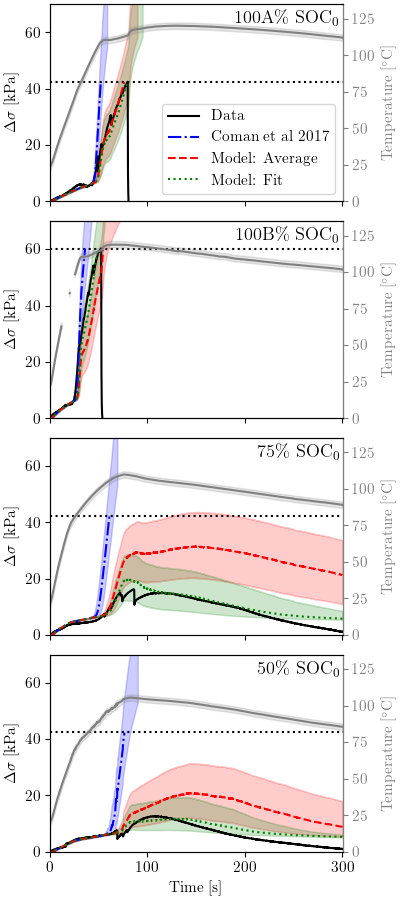

,soc,rmse_sigma,e_sigma_max,e_t_vents,t_vent_sims
0,100A,18.518432,42.310940,-29.6,50.2
1,100A,28.441742,42.385442,-12.3,67.5
2,100A,33.449369,42.333294,-9.0,70.8
3,100B,25.958492,59.896362,-19.7,32.9
4,100B,84.102062,60.189294,-1.9,50.7
5,100B,49.298245,59.965489,-8.5,44.1
6,75,23.982070,68.414167,-28.6,57.3
7,75,26.963150,27.493360,NaN,NaN
8,75,8.205340,12.490200,NaN,NaN
9,50,27.373169,71.883241,-35.6,72.6


In [28]:
# pybamm.settings.max_smoothing = 0.2
# k_As = [1, 0.09945129, 0.04428665, 0.06870394]# k_A = 0.06870394 (MSE 1e-8 50%), k_A = 0.04428665 (MSE 1e-8 75%), k_A = 0.09945129(MSE 1e-8 100% t<80s) MEAN = 0.07081396000000001
rmse_sigma = []
e_sigma_max = []
e_t_vents = []
soc_table = []
t_vent_sims = []
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})
sim_colors = ['b', 'r', 'g', 'm', 'c']
sim_linestyles = ['-.', '--', ':']*2

fig, ax= plt.subplots(len(SOC_names), 1, figsize=(4, 9), sharex = True, gridspec_kw = {'wspace':0.5, 'hspace':0.05}, constrained_layout=True) # gridspec_kw = {'wspace':0.05, 'hspace':0.2}
ax.flatten()
for i,(SOC_name,cell_solutions) in enumerate(zip(SOC_names, cells_solutions)):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    k_A_plot = [k_As[fit] for fit in ['lit','avg',SOC_name, ]]
    k_source = ['Coman et al 2017', 'Model: Average', 'Model: Fit'] #SOC_name +'\% SOC fit'
    # k_source = ['Coman et al 2017', 'Average fitted $A_{SEI}$', 'Fitted $A_{SEI}$ '] #SOC_name +'\% SOC fit'
    for j, (k_A,solutions) in enumerate(zip(k_A_plot, cell_solutions)): 
        solution = solutions[0]
        P_total = solution["Total gas pressure [kPa]"]

        chemistry = pybamm.parameter_sets.Tran2023
        param = pybamm.ParameterValues(chemistry)
        sigma_0 = data.F.iloc[0]/param['Active material surface area [m2]']/1000
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        
        sigma_plots = []
        for k, solution in enumerate(solutions): 
            sigma = solution["Cell expansion stress [kPa]"](data.t)
            sigma_plot = sigma.copy()
            if k ==0:
                vent_check = np.argmax(sigma_plot>sigma_max)
            else: 
                vent_check = np.argmax(sigma_plot>sigma_max*2)
            if vent_check > 0:
                # t_vent_sim = data.t[np.where(np.isnan(sigma_plot))[0][0]]
                t_vent_sim = data.t[np.where(sigma_plot>sigma_max)[0][0]]
                t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]] 
                sigma_plot[vent_check::] = float("nan")
                e_t_vent = t_vent_sim -  t_vent_data
            else: 
                t_vent_sim = None
                e_t_vent = None
            sigma_plots.append(sigma_plot)
            # print(e_t_vent)

        # plot solution
        data_color = 'k'
        sim_color = sim_colors[j]
        sim_ls = sim_linestyles[j]
        # plot sigma (left axis)
        if j ==0:
            ax[i].plot(data.t, data_sigma, color = data_color,   label = "Data") 
            p1, = ax[i].plot([data.t.iloc[0], data.t.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = 'k',label = '_nolegend_') 
        ax[i].plot(data.t, sigma_plots[0],linestyle=sim_ls, color = sim_color, label = k_source[j]) #$k_A$ = ' + str(k_A)
        ax[i].fill_between(data.t, sigma_plots[1],sigma_plots[2], alpha=0.2, color = sim_color)
        ax[i].set_ylim([0,70])
        ax[i].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
        ax[i].set_ylabel("$\Delta \sigma$ [kPa]")
        # plot temperature (right axis)
        T = solution["Volume-averaged cell temperature [K]"]
        if j ==0:
            ax1 = ax[i].twinx()
            p1, = ax1.plot(data.t, data.Temp2, color = 'grey', label = "Temperature") #not interpolated for 100B
            ax1.fill_between(data.t, data.Temp2 - 2.2, data.Temp2 + 2.2, alpha=0.2, color = 'grey')
            ax1.set_ylabel("Temperature [$^\circ$C]")
            ax1.yaxis.label.set_color(p1.get_color())
            ax1.tick_params(axis='y', colors=p1.get_color())
            ax1.spines.right.set_color(p1.get_color())
            ax1.set_ylim([0,135])

        ax[i].set_title(SOC_name + "\% SOC$_0$", x = 0.99, y=1.0, pad=-14, loc = 'right')
        if i ==0:
            ax[i].legend(loc = "lower right")

        # save metrics 
        soc_table.append(SOC_name)
        rmse_sigma.append(np.sqrt(np.mean((data_sigma - sigma_plot)**2)))
        e_sigma_max.append(max(sigma_plot)-max(data_sigma))
        e_t_vents.append(e_t_vent)
        t_vent_sims.append(t_vent_sim)

ax[-1].set_xlabel("Time [s]")
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 11},  bbox_to_anchor=(0.5, 0.95))#
# plt.tight_layout() # cancels constrained layout
for axs in fig.get_axes():
    axs.set_rasterized(True)
    # axs.set_rasterization_zorder(10)
plt.savefig('./figs/all_Asei_fit_avg_with_T_error.eps', format='eps', dpi = 300)
# fig.suptitle(str(int(SOC_0*100)) + "% SOC$_0$ ESC")
plt.show()

df = pd.DataFrame(list(zip(soc_table,rmse_sigma,e_sigma_max, e_t_vents, t_vent_sims)), 
                  columns= ['soc', 'rmse_sigma','e_sigma_max', 'e_t_vents','t_vent_sims'])

display(df)

# PLOT: Nominal, avg, and fit

In [25]:
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})

cells_solutions = []
for SOC_name in SOC_names:
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    k_A_plot = [k_As[fit] for fit in ['lit','avg',SOC_name]]

    cell_solutions = []
    for k_A in k_A_plot:
        cell_solutions.append(sim_venting(1,k_A).solution)
    cells_solutions.append(cell_solutions)


100A
100B
75
50


100A
100B
75
50


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


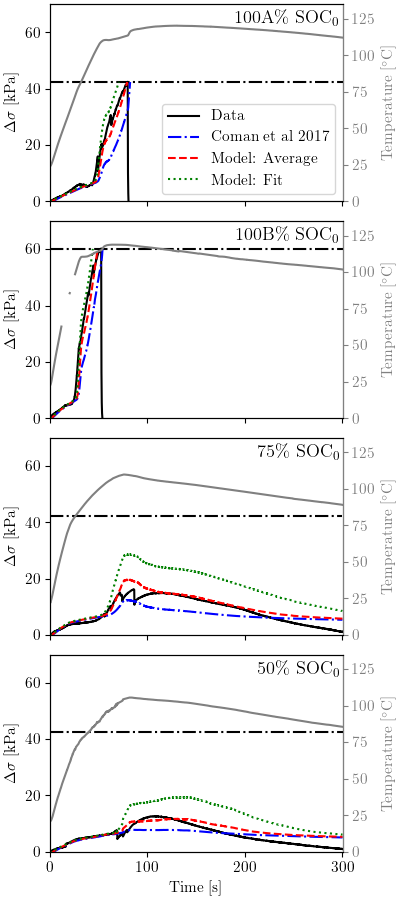

,soc,rmse_sigma,e_sigma_max,e_t_vents,t_vent_sims
0,100A,9.843144,-0.080453,2.6,82.4
1,100A,2.407298,-0.083133,-0.4,79.4
2,100A,3.259519,-0.017464,-9.0,70.8
3,100B,12.386938,-0.204170,1.5,54.1
4,100B,4.129121,-0.148568,-3.5,49.1
5,100B,3.288004,-0.127571,-8.5,44.1
6,75,3.208090,-3.751874,NaN,NaN
7,75,2.238438,3.457261,NaN,NaN
8,75,8.205340,12.490200,NaN,NaN
9,50,2.467360,-4.802607,NaN,NaN


In [10]:
# pybamm.settings.max_smoothing = 0.2
# k_As = [1, 0.09945129, 0.04428665, 0.06870394]# k_A = 0.06870394 (MSE 1e-8 50%), k_A = 0.04428665 (MSE 1e-8 75%), k_A = 0.09945129(MSE 1e-8 100% t<80s) MEAN = 0.07081396000000001
rmse_sigma = []
e_sigma_max = []
e_t_vents = []
soc_table = []
t_vent_sims = []
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})
sim_colors = ['b', 'r', 'g', 'm', 'c']
sim_linestyles = ['-.', '--', ':']*2

fig, ax= plt.subplots(len(SOC_names), 1, figsize=(4, 9), sharex = True, gridspec_kw = {'wspace':0.5, 'hspace':0.05}, constrained_layout=True) # gridspec_kw = {'wspace':0.05, 'hspace':0.2}
ax.flatten()
for i,(SOC_name,cell_solutions) in enumerate(zip(SOC_names, cells_solutions)):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    k_A_plot = [k_As[fit] for fit in ['lit','avg',SOC_name, ]]
    k_source = ['Coman et al 2017', 'Model: Average', 'Model: Fit'] #SOC_name +'\% SOC fit'
    # k_source = ['Coman et al 2017', 'Average fitted $A_{SEI}$', 'Fitted $A_{SEI}$ '] #SOC_name +'\% SOC fit'
    for j, (k_A,solution) in enumerate(zip(k_A_plot, cell_solutions)): 
        # solution = sim_venting(1,k_A).solution
        P_total = solution["Total gas pressure [kPa]"]

        chemistry = pybamm.parameter_sets.Tran2023
        param = pybamm.ParameterValues(chemistry)
        sigma_0 = data.F.iloc[0]/param['Active material surface area [m2]']/1000
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"](data.t)
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = float("nan")
            t_vent_sim = data.t[np.where(np.isnan(sigma_plot))[0][0]]
            t_vent_data = data.t.iloc[np.where(data_sigma == max(data_sigma))[0][0]] 
            e_t_vent = t_vent_sim -  t_vent_data
        else: 
            t_vent_sim = None
            e_t_vent = None

        # plot solution
        data_color = 'k'
        sim_color = sim_colors[j]
        sim_ls = sim_linestyles[j]
        # plot sigma (left axis)
        if j ==0:
            ax[i].plot(data.t, data_sigma, color = data_color,   label = "Data") 
            p1, = ax[i].plot([data.t.iloc[0], data.t.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=sim_ls, color = data_color,label = '_nolegend_') 
        ax[i].plot(data.t, sigma_plot,linestyle=sim_ls, color = sim_color, label = k_source[j]) #$k_A$ = ' + str(k_A)
        ax[i].set_ylim([0,70])
        ax[i].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
        ax[i].set_ylabel("$\Delta \sigma$ [kPa]")
        # plot temperature (right axis)
        T = solution["Volume-averaged cell temperature [K]"]
        if j ==0:
            ax1 = ax[i].twinx()
            p1, = ax1.plot(data.t, data.Temp2, color = 'grey', label = "Temperature") #not interpolated for 100B
            ax1.set_ylabel("Temperature [$^\circ$C]")
            ax1.yaxis.label.set_color(p1.get_color())
            ax1.tick_params(axis='y', colors=p1.get_color())
            ax1.spines.right.set_color(p1.get_color())
            ax1.set_ylim([0,135])

        ax[i].set_title(SOC_name + "\% SOC$_0$", x = 0.99, y=1.0, pad=-14, loc = 'right')
        if i ==0:
            ax[i].legend(loc = "lower right")

        # save metrics 
        soc_table.append(SOC_name)
        rmse_sigma.append(np.sqrt(np.mean((data_sigma - sigma_plot)**2)))
        e_sigma_max.append(max(sigma_plot)-max(data_sigma))
        e_t_vents.append(e_t_vent)
        t_vent_sims.append(t_vent_sim)

ax[-1].set_xlabel("Time [s]")
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=2, prop={'size': 11},  bbox_to_anchor=(0.5, 0.95))#
# plt.tight_layout() # cancels constrained layout
plt.savefig('./figs/all_Asei_fit_avg.eps', format='eps', dpi = 300)
# fig.suptitle(str(int(SOC_0*100)) + "% SOC$_0$ ESC")
plt.show()

df = pd.DataFrame(list(zip(soc_table,rmse_sigma,e_sigma_max, e_t_vents, t_vent_sims)), 
                  columns= ['soc', 'rmse_sigma','e_sigma_max', 'e_t_vents','t_vent_sims'])
display(df)

# PLOT: Fit only

100A
100B
75
50


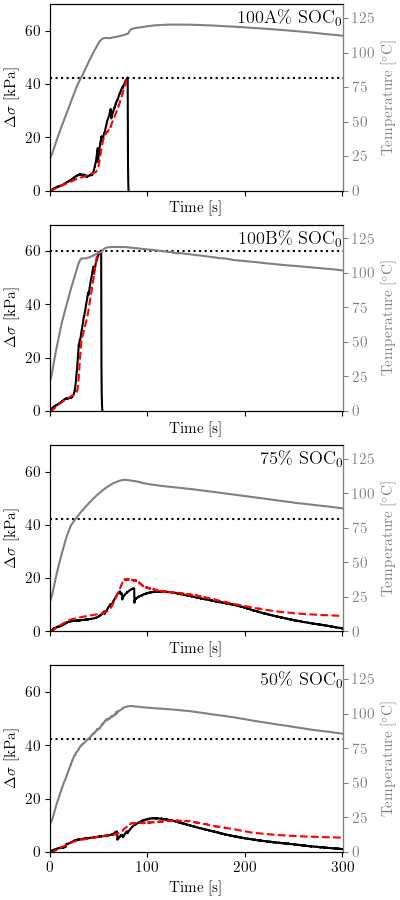

,SOC_names,rmse_sigma,e_sigma_max,e_t_vents
0,100A,2.407298,-0.083133,-0.4
1,100B,4.129121,-0.148568,-3.5
2,75,2.238438,3.457261,NaN
3,50,2.244012,-0.948083,NaN


In [11]:
# pybamm.settings.max_smoothing = 0.2
# k_As = [1, 0.09945129, 0.04428665, 0.06870394]# k_A = 0.06870394 (MSE 1e-8 50%), k_A = 0.04428665 (MSE 1e-8 75%), k_A = 0.09945129(MSE 1e-8 100% t<80s) MEAN = 0.07081396000000001
rmse_sigma = []
e_sigma_max = []
e_t_vents = []
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1})
k_source.append('Average')
sim_colors = ['r', 'g', 'b', 'm', 'c']
fig, ax= plt.subplots(len(SOC_names), 1, figsize=(4, 9), sharex = True, layout="constrained")
ax.flatten()

for i,(SOC_name) in enumerate(SOC_names):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    k_A = k_As[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)

    solution = sim_venting(1,k_A).solution
    P_total = solution["Total gas pressure [kPa]"]

    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    sigma_0 = data.F.iloc[0]/param['Active material surface area [m2]']/1000
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"](data.t)
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = float("nan")
        t_vent_sim = data.t[np.where(np.isnan(sigma_plot))[0][0]]
        t_vent_data = data.t.iloc[np.where(data_sigma == sigma_max)[0][0]] 
        e_t_vent = t_vent_sim -  t_vent_data
    else: 
        e_t_vent = float('nan')

    # plot solution
    data_color = 'k'
    sim_color = sim_colors[0]
    sim_ls = '--'
    # plot sigma (left axis)
    # if j ==0:
    ax[i].plot(data.t, data_sigma, color = data_color,   label = "Data") 
    p1, = ax[i].plot([data.t.iloc[0], data.t.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color,label = '_nolegend_') 
    ax[i].plot(data.t, sigma_plot,linestyle=sim_ls, color = sim_color) #$k_A$ = ' + str(k_A)
    ax[i].set_ylim([0,70])
    ax[i].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
    ax[i].set_ylabel("$\Delta \sigma$ [kPa]")
    ax[i].set_xlabel("Time [s]")
    # plot temperature (right axis)
    T = solution["Volume-averaged cell temperature [K]"]
    ax1 = ax[i].twinx()
    p1, = ax1.plot(data.t, data.Temp, color = 'gray', label = "Temperature")
    ax1.set_ylabel("Temperature [$^\circ$C]")
    ax1.yaxis.label.set_color(p1.get_color())
    ax1.tick_params(axis='y', colors=p1.get_color())
    ax1.spines.right.set_color(p1.get_color())
    ax1.set_ylim([0,135])

    ax[i].set_title(SOC_name + "\% SOC$_0$", y=1.0, pad=-14, loc = 'right')
    # if i ==0:
    #     ax[i].legend(loc = "lower right")

    rmse_sigma.append(np.sqrt(np.mean(np.square(data_sigma-sigma_plot))))
    e_sigma_max.append(max(sigma_plot) - max(data_sigma))
    e_t_vents.append(e_t_vent)
plt.savefig('./figs/Asei_fits_separate.eps', format='eps', dpi = 300)
# fig.suptitle(str(int(SOC_0*100)) + "% SOC$_0$ ESC")
# plt.tight_layout()
plt.show()

df = pd.DataFrame(list(zip(SOC_names,rmse_sigma,e_sigma_max, e_t_vents)), 
                  columns= ['SOC_names','rmse_sigma','e_sigma_max', 'e_t_vents'])
display(df)

# PLOT: Results with ALL $A_{SEI}$

In [66]:
# pybamm.settings.max_smoothing = 0.2
# k_As = [1, 0.09945129, 0.04428665, 0.06870394]# k_A = 0.06870394 (MSE 1e-8 50%), k_A = 0.04428665 (MSE 1e-8 75%), k_A = 0.09945129(MSE 1e-8 100% t<80s) MEAN = 0.07081396000000001

SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

k_As = [1, 0.05716926, 0.04571944, 0.07912785, 0.238155]# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_source = ['Nominal', '50\% SOC fit', '75\% SOC fit', '100A\% SOC fit', '100B\% SOC fit']
sim_colors = ['r', 'g', 'b', 'm', 'c']
fig, ax= plt.subplots(len(SOC_names), 1, figsize=(4, 9), sharex = True, layout="constrained")
ax.flatten()
for i,SOC_name in enumerate(SOC_names):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)

    for j, k_A in enumerate(k_As): 
        solution = sim_venting(1,k_A).solution
        P_total = solution["Total gas pressure [kPa]"]

        chemistry = pybamm.parameter_sets.Tran2023
        param = pybamm.ParameterValues(chemistry)
        sigma_0 = data.F.iloc[0]/param['Active material surface area [m2]']/1000
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"](data.t)
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = float("nan")

        # plot solution
        data_color = 'k'
        sim_color = sim_colors[j]
        sim_ls = '--'
        # plot sigma (left axis)
        if j ==0:
            ax[i].plot(data.t, data_sigma, color = data_color,   label = "Data") 
            p1, = ax[i].plot([data.t.iloc[0], data.t.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=sim_ls, color = data_color,label = '_nolegend_') 
        ax[i].plot(data.t, sigma_plot,linestyle=sim_ls, color = sim_color, label = k_source[j]) #$k_A$ = ' + str(k_A)
        ax[i].set_ylim([0,70])
        ax[i].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
        ax[i].set_ylabel("$\Delta \sigma$ [kPa]")
        ax[i].set_xlabel("Time [s]")
        # plot temperature (right axis)
        T = solution["Volume-averaged cell temperature [K]"]
        if j ==0:
            ax1 = ax[i].twinx()
            p1, = ax1.plot(data.t, data.Temp2, color = 'gray', label = "Temperature") #not interpolated for 100B
            ax1.set_ylabel("Temperature [$^\circ$C]")
            ax1.yaxis.label.set_color(p1.get_color())
            ax1.tick_params(axis='y', colors=p1.get_color())
            ax1.spines.right.set_color(p1.get_color())
            ax1.set_ylim([0,135])

        ax[i].set_title(SOC_name + "\% SOC$_0$", y=1.0, pad=-14, loc = 'right')
        if i ==0:
            ax[i].legend(loc = "lower right")

plt.savefig('./figs/all_Asei_fit.eps', format='eps', dpi = 300)
# fig.suptitle(str(int(SOC_0*100)) + "% SOC$_0$ ESC")
# plt.tight_layout()
plt.show()

100A


100A
100B
75
50


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


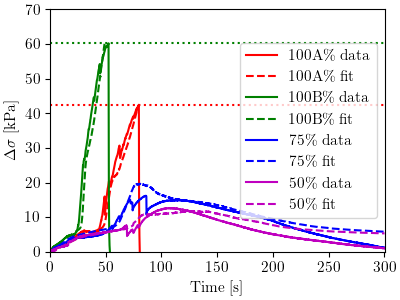

In [12]:
# pybamm.settings.max_smoothing = 0.2
# k_As = [1, 0.09945129, 0.04428665, 0.06870394]# k_A = 0.06870394 (MSE 1e-8 50%), k_A = 0.04428665 (MSE 1e-8 75%), k_A = 0.09945129(MSE 1e-8 100% t<80s) MEAN = 0.07081396000000001

SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}
k_As = {'100A': 0.07912785, '100B': 0.238155, '75': 0.04571944, '50': 0.05716926}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
k_As.update({'avg': np.mean([k_As[k] for k in k_As.keys()])})
k_As.update({'lit':1.67E15})
sim_colors = ['r', 'g', 'b', 'm', 'c']
fig, ax= plt.subplots(1, 1, figsize=(4, 3),layout="constrained")
# ax.flatten()
for i,(SOC_name) in enumerate(SOC_names):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    k_A = k_As[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)

    solution = sim_venting(1,k_A).solution
    P_total = solution["Total gas pressure [kPa]"]

    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    sigma_0 = data.F.iloc[0]/param['Active material surface area [m2]']/1000
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"](data.t)


    # plot solution
    data_color = sim_colors[i]
    sim_color = sim_colors[i]
    sim_ls = '--'
    # plot sigma (left axis)
    # if j ==0:
    ax.plot(data.t, data_sigma, color = data_color,label = SOC_name + '\% data') 
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = float("nan")
        ax.plot([data.t.iloc[0], data.t.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=':', color = data_color) 
    ax.plot(data.t, sigma_plot,linestyle=sim_ls, color = sim_color,label = SOC_name + '\% fit') #$k_A$ = ' + str(k_A)
    ax.set_ylim([0,70])
    ax.set_xlim([data.t.iloc[0], data.t.iloc[-1]])
    ax.set_ylabel("$\Delta \sigma$ [kPa]")
    ax.set_xlabel("Time [s]")
    # plot temperature (right axis)
    # T = solution["Volume-averaged cell temperature [K]"]
    # ax1 = ax[i].twinx()
    # p1, = ax1.plot(data.t, data.Temp, color = 'gray', label = "Temperature")
    # ax1.set_ylabel("Temperature [$^\circ$C]")
    # ax1.yaxis.label.set_color(p1.get_color())
    # ax1.tick_params(axis='y', colors=p1.get_color())
    # ax1.spines.right.set_color(p1.get_color())
    # ax1.set_ylim([0,135])

    # ax[i].set_title(SOC_name + "\% SOC$_0$", y=1.0, pad=-14, loc = 'right')
    ax.legend(loc = "right")

plt.savefig('./figs/Asei_fits_single.eps', format='eps', dpi = 300)
# fig.suptitle(str(int(SOC_0*100)) + "% SOC$_0$ ESC")
# plt.tight_layout()
plt.show()